# [DAS509] 5강 Python을 활용한 시각화 기초

- 시각화 (Visualization)은 데이터 분석에서 매우 중요함
- 다양한 시각화 도구가 있음
    - Matplotllib - Basic Tool in Python
    - Seaborn - Statistical Plots
    - Pandas.DataFrame.plot - Directly from Pandas.DataFrame
    - Plotnine: a Grammer of Graphics in Python (ggplot2 in R)

- 시각화의 종류
    - 기술적 시각화 (Descriptive Visualization)
        - 1변수 요약
        - 관계의 요약
            - 2변수
            - 3변수 이상
        - 데이터의 종류에 따라 다양한 방법론이 있음
            - 연속형 / 비율형 / 범주형 / 순서형
            - 텍스트, 시공간 등
    
    - 분석적 시각화 (Analytical Visualization) : 모델링 자체 혹은 모델링 결과의 시각화
        - Dimension Reduction
        - Clustering
        - Graphical Model / Network Analysis
        - ROC analysis

# Matplotlib

- Python 시각화의 기본 ([https://matplotlib.org](https://matplotlib.org/stable/index.html))

In [1]:
import numpy as np
import pandas as pd

#!pip install matplotlib
import matplotlib.pyplot as plt

- 두가지의 코딩 방법이 있음
    - Explicit: 다소 덜 직관적이지만 customization에 용이함

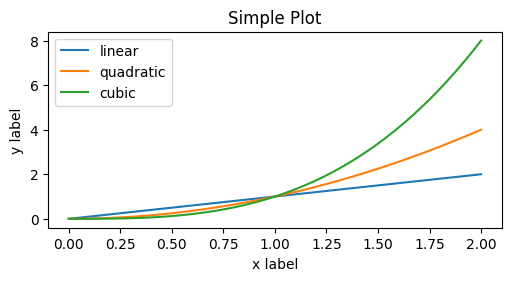

In [4]:
x = np.linspace(0, 2, 100)  # Sample data.

# Note that even in the OO-style, we use `.pyplot.figure` to create the Figure.
fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
ax.plot(x, x, label='linear')  # Plot some data on the axes.
ax.plot(x, x**2, label='quadratic')  # Plot more data on the axes...
ax.plot(x, x**3, label='cubic')  # ... and some more.
ax.set_xlabel('x label')  # Add an x-label to the axes.
ax.set_ylabel('y label')  # Add a y-label to the axes.
ax.set_title("Simple Plot")  # Add a title to the axes.
ax.legend()  # Add a legend.

- Implicit: 직관적인 반면 customization이 불편함

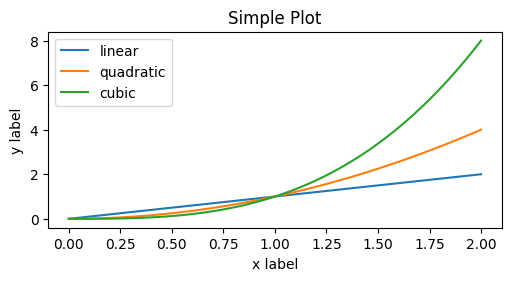

In [180]:
plt.figure(figsize=(5, 2.7), layout='constrained') # optional
plt.plot(x, x, label='linear')  # Plot some data on the (implicit) axes.
plt.plot(x, x**2, label='quadratic')  # etc.
plt.plot(x, x**3, label='cubic')
plt.xlabel('x label')
plt.ylabel('y label')
plt.title("Simple Plot")
plt.legend()

## Explicit한 방법

- Figure 객체: 그림을 그리기 위한 (빈) 객체

In [3]:
fig = plt.figure()
fig = plt.figure(figsize = (5,5), layout = 'constrained')

<Figure size 640x480 with 0 Axes>

<Figure size 500x500 with 0 Axes>

- Figure는 빈 객체일 뿐, 최소 하나이상의 subplot을 생성해야함
- 한번에 하나씩 subplot을 생성하는 법(add_subplot)

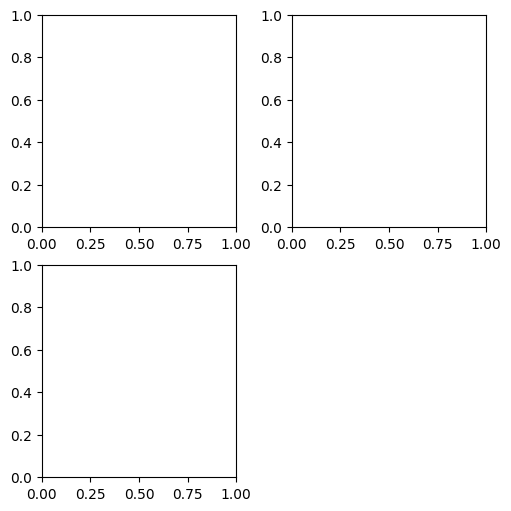

In [182]:
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

# 출력 (빈 객체)
fig

- 여전히 ax1 - ax3은 빈 객체. 이제 그림을 그려보자.

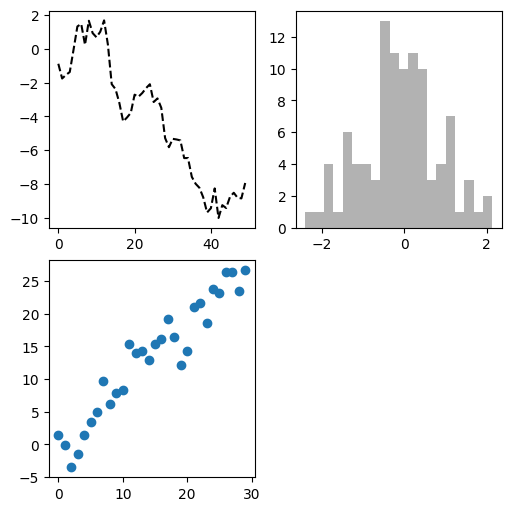

In [183]:
# 1변량 trend
ax1.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed")

# Histogram
ax2.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3)

# Satter Plot (산점도)
ax3.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))

# 출력
fig

- 한번에 그리는 방법 (subplots)

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

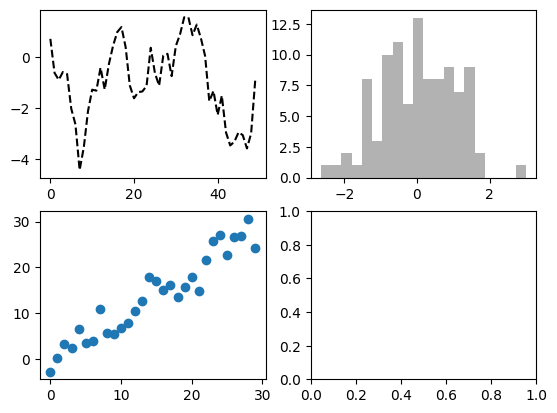

In [7]:
fig, axes = plt.subplots(2, 2)
axes[0,0].plot(np.random.standard_normal(50).cumsum(), 
               color="black", 
               linestyle="dashed")

axes[0,1].hist(np.random.standard_normal(100), 
               bins=20, 
               color="black", 
               alpha=0.3)
               
axes[1,0].scatter(np.arange(30), 
                  np.arange(30) + 3 * np.random.standard_normal(30))

axes

- matplotlib.pyplot.subplots 주요 옵션

| 인수 | 설명 |
| --- | --- |
| nrows | Integer - 서브플롯의 행 수 |
| ncols | Integer - 서브플롯의 열 수 |
| sharex | Logical - 모든 서브플롯이 동일한 x축을 사용할 것인가 여부 |
| sharey | Logical - 모든 서브플롯이 동일한 축y을 사용할 것인가 여부 |

## 그림의 종류

- Association
- Distribution
- Gridded
- 3-dimensional: Avoid!

### M.1.1 Line Plot - *plot(x, y)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html#matplotlib.axes.Axes.plot

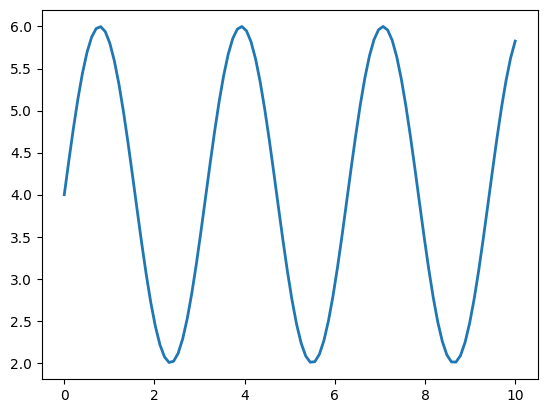

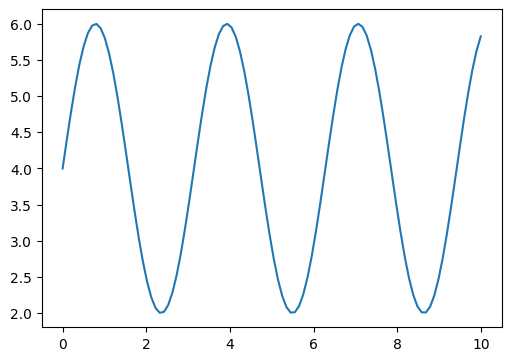

In [9]:
x = np.linspace(0, 10, 100)
y = 4 + 2 * np.sin(2 * x)

# Ex
fig, ax = plt.subplots()
ax.plot(x, y, linewidth=2.0)

# Im
plt.figure(figsize=(5, 3.5), layout='constrained') # optional
plt.plot(x,y)

### M.1.2 Scatter Plot - *scatter(x, y)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html#matplotlib.axes.Axes.scatter

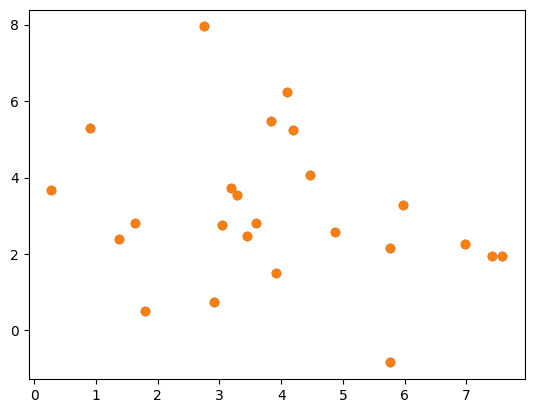

In [10]:
# make the data
np.random.seed(3)
x = 4 + np.random.normal(0, 2, 24)
y = 4 + np.random.normal(0, 2, len(x))

# Explicitly
fig, ax = plt.subplots()
ax.scatter(x, y)

# Implicitly
plt.scatter(x,y)

### M.1.3 Bar Plot - ***bar(x, height)***

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html#matplotlib.axes.Axes.bar

<BarContainer object of 8 artists>

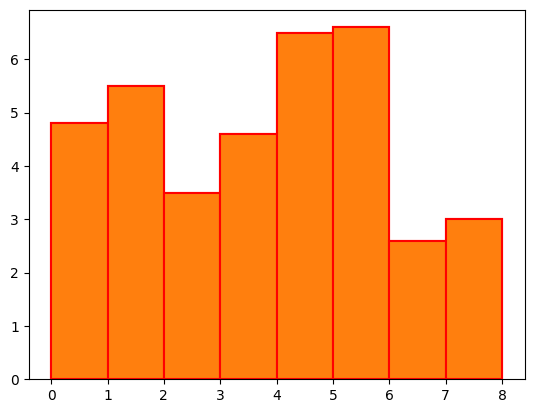

In [188]:
# make data:
x = 0.5 + np.arange(8)
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# Explicitly
fig, ax = plt.subplots()
ax.bar(x, y, width = 1, edgecolor = "red", linewidth = 1.5)

# Implicitly
plt.bar(x, y, width = 1, edgecolor = "red", linewidth = 1.5)

### M.1.4 Stem Plot - *stem(x, y)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.stem.html#matplotlib.axes.Axes.stem

<StemContainer object of 3 artists>

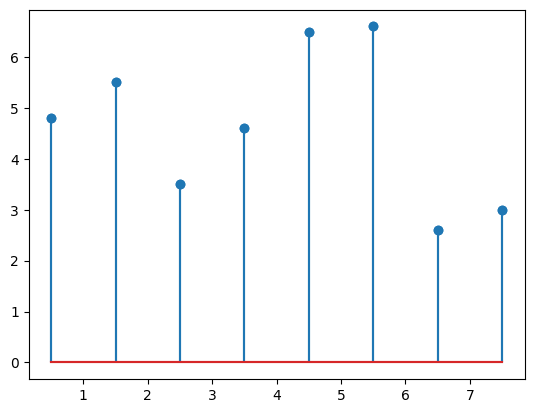

In [189]:
# Explicitly
fig, ax = plt.subplots()
ax.stem(x, y)

# Implicitly
plt.stem(x, y)

### M.1.5 Line Plot with Uncertainty - ***fill_between(x, y1, y2)***

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html#matplotlib.axes.Axes.fill_between

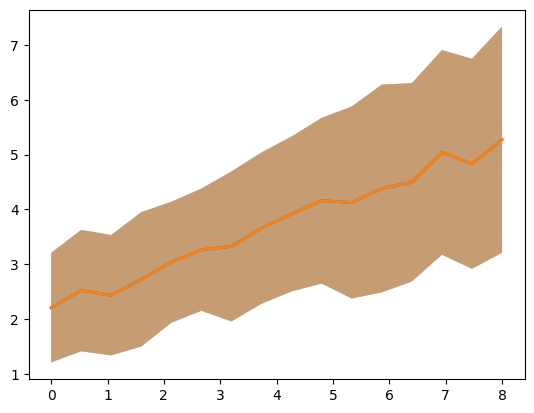

In [11]:
# make data
np.random.seed(1)
x = np.linspace(0, 8, 16)
y1 = 3 + 4*x/8 + np.random.uniform(0.0, 0.5, len(x)) # upper values
y2 = 1 + 2*x/8 + np.random.uniform(0.0, 0.5, len(x)) # lower values

# Explicitly
fig, ax = plt.subplots()
ax.fill_between(x, y1, y2, alpha=.5, linewidth=0) # Uncertainty
ax.plot(x, (y1 + y2)/2, linewidth=2)              # Line

# Implicitly
plt.fill_between(x, y1, y2, alpha=.5, linewidth=0) # Uncertainty
plt.plot(x, (y1 + y2)/2, linewidth=2)              # Line

### M.1.6 Stack Plot - ***stackplot(x, y)***

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.stackplot.html#matplotlib.axes.Axes.stackplot

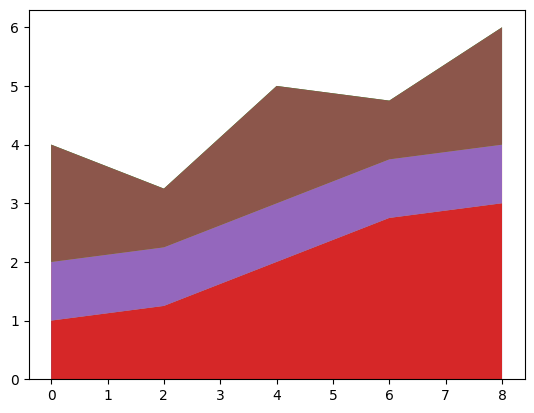

In [13]:
# make data
x = np.arange(0, 10, 2)
ay = [1, 1.25, 2, 2.75, 3]
by = [1, 1, 1, 1, 1]
cy = [2, 1, 2, 1, 2]
y = np.vstack([ay, by, cy]) # 3 * 5 array


# Explicitly
fig, ax = plt.subplots()
ax.stackplot(x, y)

# Implicitly
plt.stackplot(x, y)

### M.1.6 Stair Plot - ***stairs(values)***

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.stairs.html#matplotlib.axes.Axes.stairs

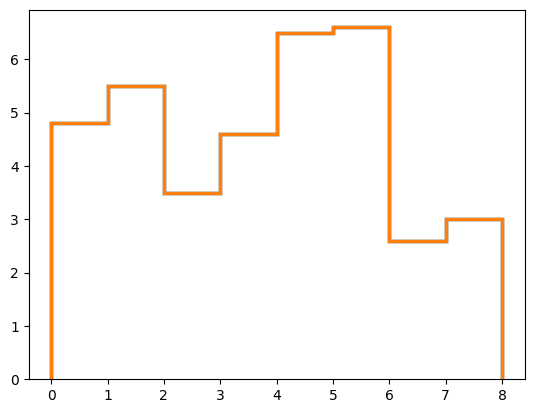

In [193]:
# make data
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# Explicitly
fig, ax = plt.subplots()
ax.stairs(y, linewidth=2.5)

# Implicitly
plt.stairs(y, linewidth=2.5)

## M.2. 분포(Distribution)의 요약 

### M.2.1 히스토그램 - *hist(x)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html#matplotlib.axes.Axes.hist

(array([ 6.,  9., 32., 47., 53., 37., 10.,  6.]),
 array([0.34774335, 1.2783365 , 2.20892966, 3.13952281, 4.07011596,
        5.00070911, 5.93130226, 6.86189541, 7.79248856]),
 <BarContainer object of 8 artists>)

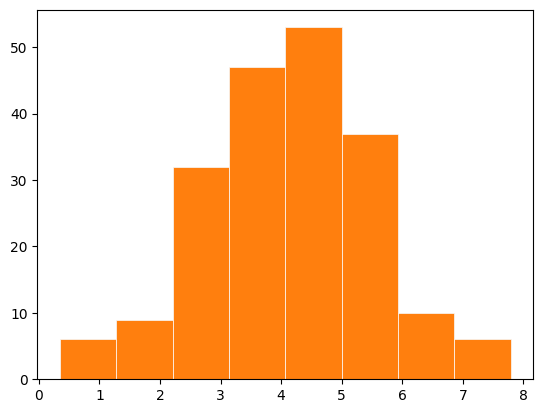

In [194]:

# make data
np.random.seed(1)
x = 4 + np.random.normal(0, 1.5, 200)

# plot:
fig, ax = plt.subplots()
ax.hist(x, bins=8, linewidth=0.5, edgecolor="white")

# or
plt.hist(x, bins=8, linewidth=0.5, edgecolor="white")

### M.2.2 상자(& 수염) 그림 - *box(x)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html#matplotlib.axes.Axes.boxplot

{'whiskers': [<matplotlib.lines.Line2D at 0x1e5b91787d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1e5b9179e10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e5b916fc50>,
 'medians': [<matplotlib.lines.Line2D at 0x1e5b917b550>,
 'fliers': [<matplotlib.lines.Line2D at 0x1e5b9184050>,
 'means': []}

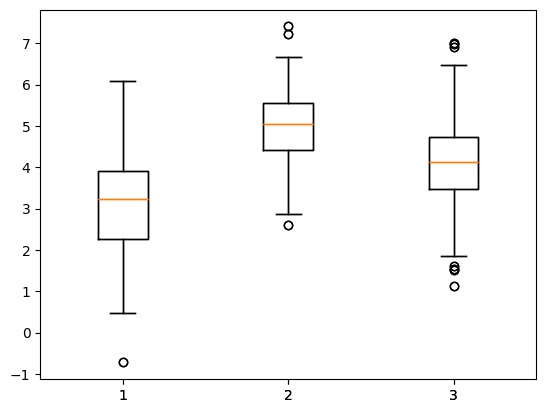

In [195]:
# make data:
np.random.seed(10)
Data = np.random.normal((3, 5, 4), (1.25, 1.00, 1.25), (100, 3))
Data

# plot:
fig, ax = plt.subplots()
ax.boxplot(Data)

# or 
plt.boxplot(Data)

### M.2.3 신뢰구간 - *errorbar(x, y, yerr, xerr)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html#matplotlib.axes.Axes.errorbar

<ErrorbarContainer object of 3 artists>

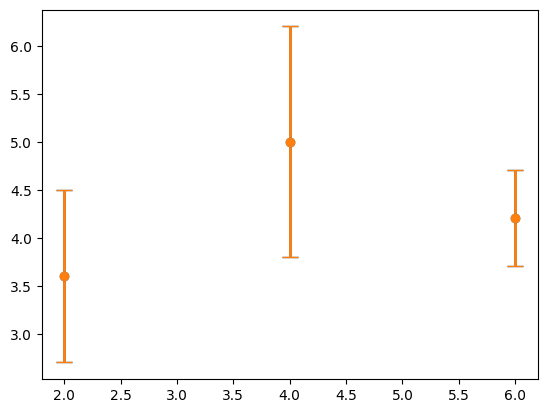

In [196]:
# make data:
x = [2, 4, 6]
y = [3.6, 5, 4.2]
yerr = [0.9, 1.2, 0.5] # margin of error

# plot:
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr, fmt='o', linewidth=2, capsize=6)

# or
plt.errorbar(x, y, yerr, fmt='o', linewidth=2, capsize=6)

### M.2.4 바이올린 플랏 - *violinplot(D)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.violinplot.html#matplotlib.axes.Axes.violinplot

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x1e5b905f210>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x1e5b8f87e90>,
 'cmins': <matplotlib.collections.LineCollection at 0x1e5b8f99410>,
 'cbars': <matplotlib.collections.LineCollection at 0x1e5b8f9a910>}

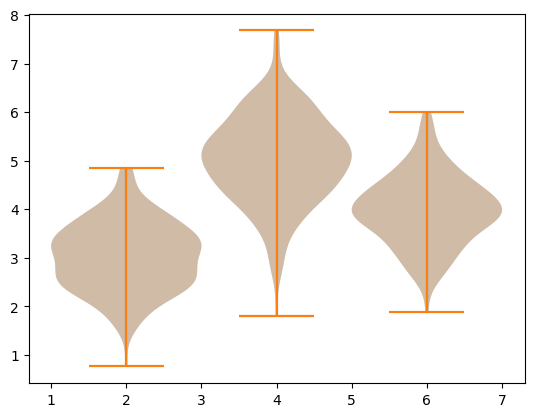

In [197]:
# make data:
np.random.seed(10)
Data = np.random.normal((3, 5, 4), (0.75, 1.00, 0.75), (200, 3))

# plot:
fig, ax = plt.subplots()
vp = ax.violinplot(Data, positions = [2, 4, 6], widths = 2)

# or 
plt.violinplot(Data, positions = [2, 4, 6], widths = 2)


### M.2.5 이벤트 플랏 - *eventplot(D)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.eventplot.html#matplotlib.axes.Axes.eventplot

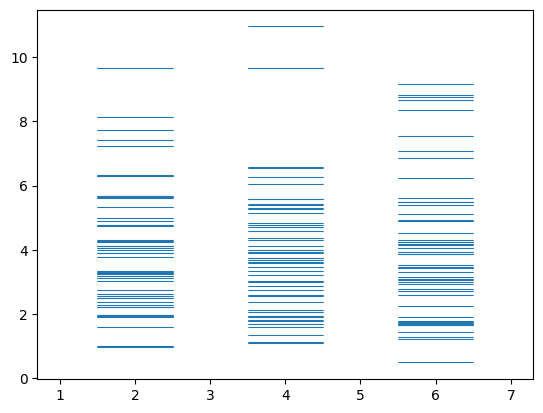

In [198]:
# make data:
np.random.seed(1)
x = [2, 4, 6]
Data = np.random.gamma(4, size=(3, 50))

# plot:
fig, ax = plt.subplots()
ax.eventplot(Data, orientation="vertical", lineoffsets=x, linewidth=0.75)

# or
plt.eventplot(Data, orientation="vertical", lineoffsets=x, linewidth=0.75)

### M.2.6 이변량 히스토그램 - *hist2d(x, y)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist2d.html#matplotlib.axes.Axes.hist2d

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(59, 59)),
 array([-3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
        -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
        -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
        -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
        -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
        -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
        -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
        -2.00000000e-01, -1.00000000e-01,  2.66453526e-15,  1.00000000e-01,
         2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
         6.00000000e-01,  7.00000000e-01,  8.000000

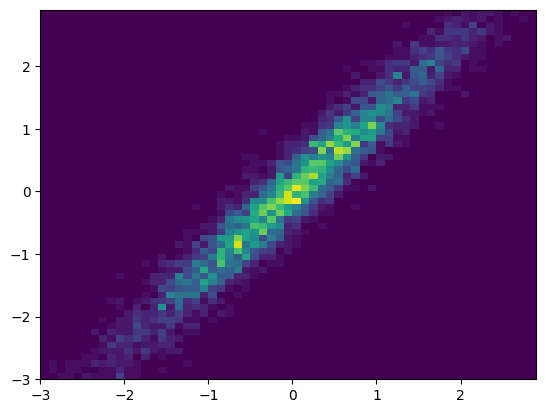

In [14]:
# make data: regression
np.random.seed(1)
x = np.random.randn(5000)
y = 1.2 * x + np.random.randn(5000) / 3

# plot:
fig, ax = plt.subplots()
ax.hist2d(x, y, bins=(np.arange(-3, 3, 0.1), np.arange(-3, 3, 0.1)))

# or 
plt.hist2d(x, y, bins=(np.arange(-3, 3, 0.1), np.arange(-3, 3, 0.1)))

### M.2.7 Hexbin 차트 - *hexbin(x, y, C)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hexbin.html#matplotlib.axes.Axes.hexbin

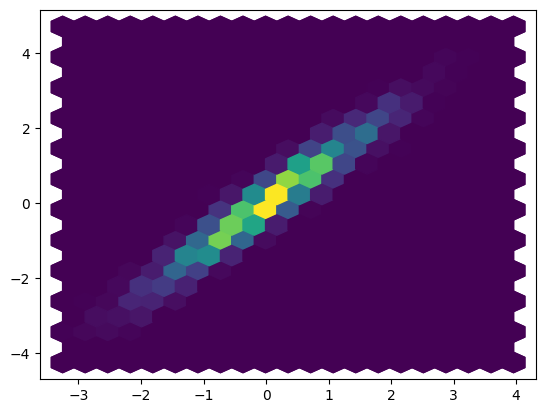

In [200]:
# plot:
fig, ax = plt.subplots()
ax.hexbin(x, y, gridsize=20)

# or
plt.hexbin(x, y, gridsize=20)

### M.2.8 파이차트 - *pie(x)*

- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.pie.html#matplotlib.axes.Axes.pie

([<matplotlib.patches.Wedge at 0x1e5b950f090>,
 [Text(7.138486499000184, 5.019756096129642, ''),
  Text(5.019756022668064, 7.1384865228692975, ''),
  Text(0.8615134293924815, 5.019755875744905, ''),
  Text(5.019756463437526, 0.861513620345407, '')])

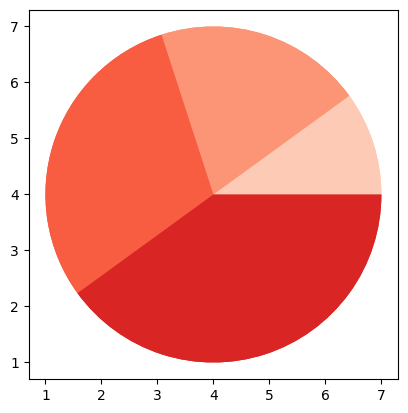

In [201]:
# make data
x = [1, 2, 3, 4]
colors = plt.get_cmap('Reds')(np.linspace(0.2, 0.7, len(x)))

# plot
fig, ax = plt.subplots()
ax.pie(x, colors = colors, radius = 3, center = (4, 4), frame = True)

# or
plt.pie(x, colors = colors, radius = 3, center = (4, 4), frame = True)

### M.3. 격자를 활용한 그림

M.3.1. Gridded Surface Plot - pcolormesh(x, y, z)

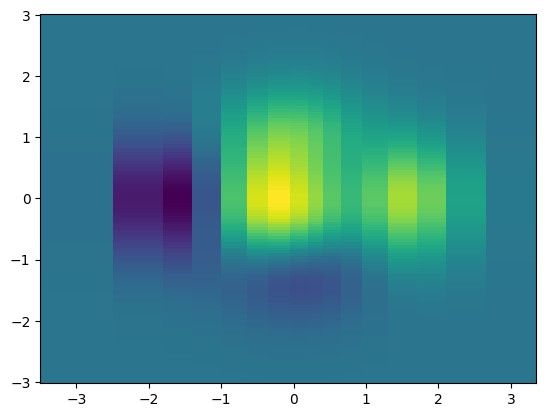

In [203]:
# make data with uneven sampling in x
x = [-3, -2, -1.6, -1.2, -.8, -.5, -.2, .1, .3, .5, .8, 1.1, 1.5, 1.9, 2.3, 3]
X, Y = np.meshgrid(x, np.linspace(-3, 3, 128))
Z = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)

# plot
fig, ax = plt.subplots()
ax.pcolormesh(X, Y, Z)

# or
plt.pcolormesh(X, Y, Z)

M.3.2 Contour Plot - contour(x, y, z, levels) or contourf(x, y, z, levels)

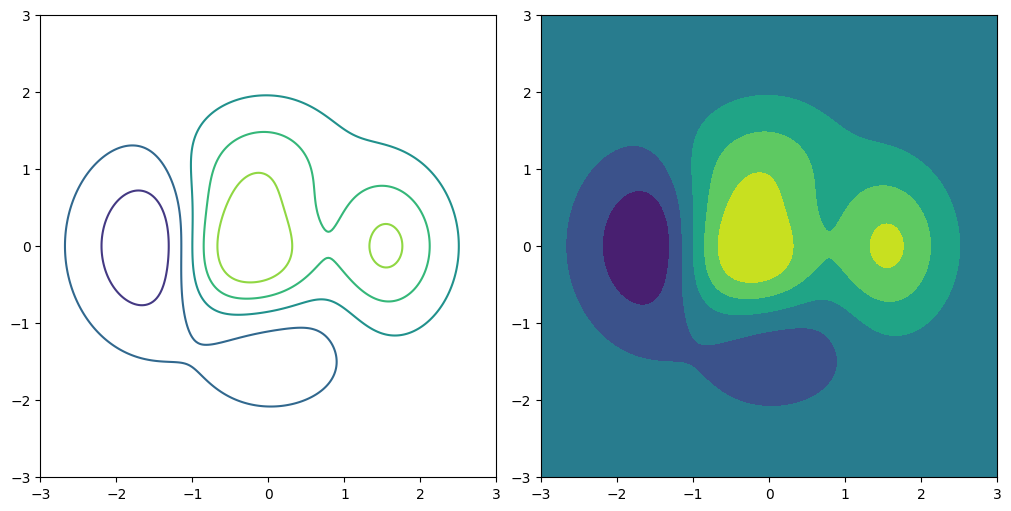

In [204]:
# make data
X, Y = np.meshgrid(np.linspace(-3, 3, 256), np.linspace(-3, 3, 256))
Z = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)
levels = np.linspace(np.min(Z), np.max(Z), 7)

# plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')
ax[0].contour(X, Y, Z, levels=levels)  # lines
ax[1].contourf(X, Y, Z, levels=levels) # colors

## M.4. 그림 조정하기

### M.4.1 subplot 크기와 조정

- 기본적으로 적당한 간격 (spacing)과 여백 (padding)을 제공
- 이를 조정하기 위해서는 subplot_adjust 메서드를 활용 (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots_adjust.html)

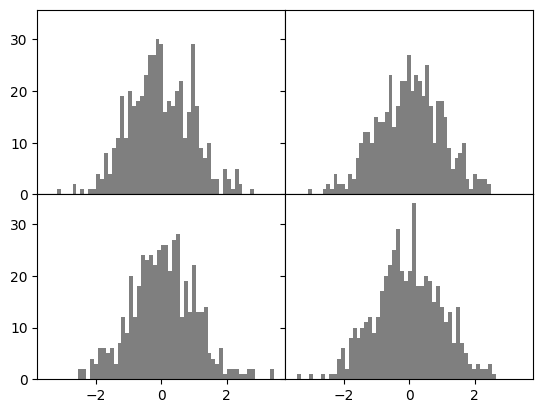

In [19]:
fig, axes = plt.subplots(2, 2, sharex = True, sharey = True)
for i in range(2):
   for j in range(2):
      axes[i, j].hist(np.random.standard_normal(500), 
                      bins = 50, 
                      color = "black", 
                      alpha = 0.5)
fig.subplots_adjust(wspace = 0, hspace = 0)

M.4.2 색상, 마커, 선 스타일

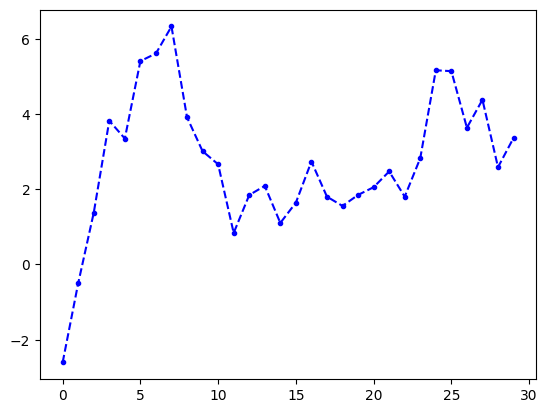

In [23]:
fig, ax = plt.subplots()

ax.plot(np.random.standard_normal(30).cumsum(), 
        color = "b",
        linestyle = "dashed",
        marker = ".")

- **색상**

| 기호 | 컬러 |
| --- | --- |
| ‘b’ | blue |
| ‘g’ | green |
| ‘r’ | red |
| ‘c’ | cyan |
| ‘m’ | magenta |
| ‘y’ | yellow |
| ‘k’ | black |
| ‘w’ | white |

-마커: https://matplotlib.org/stable/api/markers_api.html

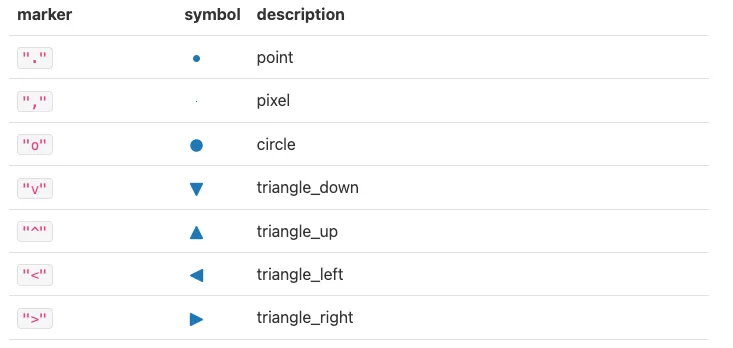

- **선스타일**

| **linestyle** | 설명 |
| --- | --- |
| ‘-’ or ‘solid’ | solid line |
| '--' or 'dashed' | dashed line |
| '-.' or 'dashdot' | dash-dotted line |
| ':' or 'dotted' | dotted line |
| 'None' or ‘  ‘ or ‘’ | draw nothing |
| Custom Style | https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html |

M.4.3 눈금, 레이블, 범례

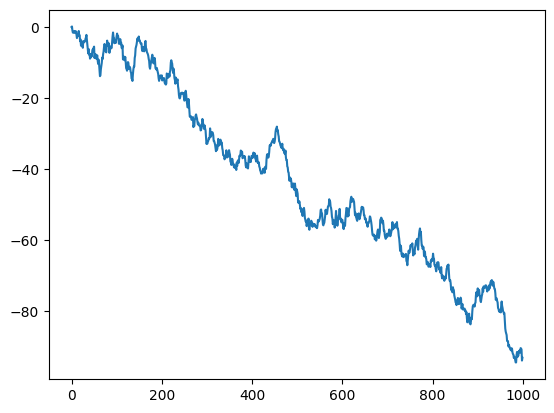

In [25]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum());

- 눈금의 변경
    - set_xticks / set_yticks: 눈금의 위치를 조정

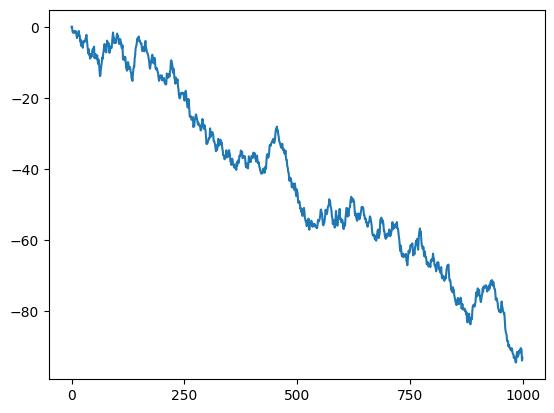

In [26]:
ax.set_xticks([0,250,500,750,1000])
fig

- set_xticklables / set_yticklables: 눈금을 레이블을 변경

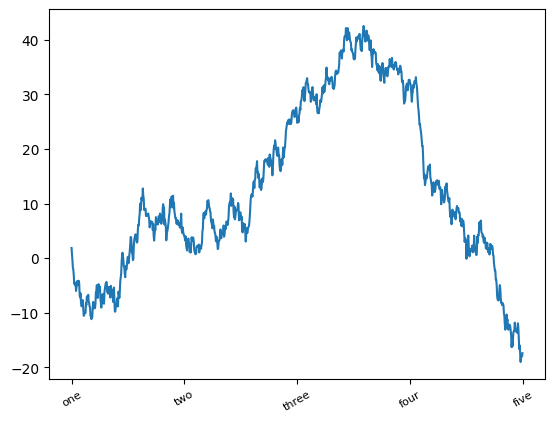

In [209]:
ax.set_xticklabels(["one", "two", "three", "four", "five"], 
                   rotation = 30, fontsize = 8)
fig

- 레이블
    - set_xlable / set_ylabel: 축의 이름 변경

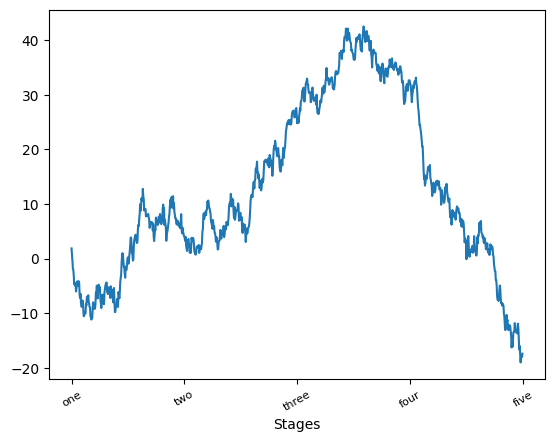

In [210]:
ax.set_xlabel("Stages")
fig

- set_title: 그림의 제목

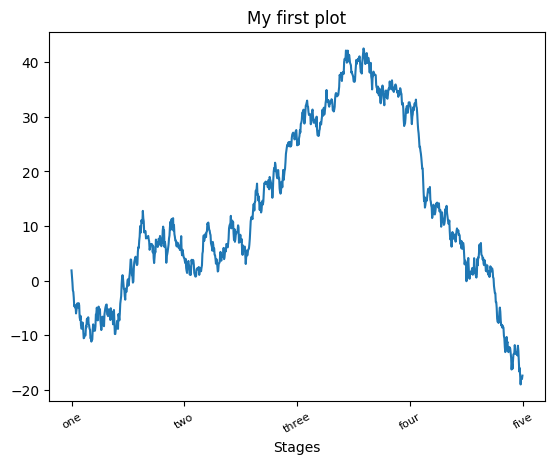

In [211]:
ax.set_title("My first plot")
fig

- 범례
    - 범례를 추가하는 가장 간단한 방법은 각 그래프에 label 인수를 넘기는 것

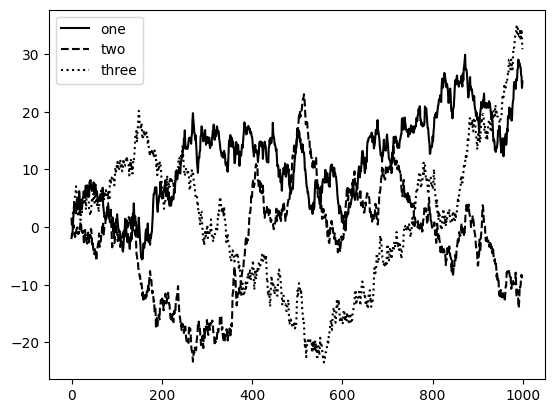

In [27]:
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color="black", label="one")
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dashed",
        label="two")
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dotted",
        label="three")

ax.legend()

### M.4.4 그림 파일로 저장하기

- savefig 메서드를 이용

In [213]:
plt.savefig("figpath.png", dpi = 400)

<Figure size 640x480 with 0 Axes>

| 인수 | 설명 |
| --- | --- |
| fname | 파일경로 및 파일명. 저장되는 포맷은 확장자를 통해 결정 |
| dpi | 해상도 (Dots Per Inch) |
| facecolor, edgecolor | 서브플랏의 배경 색상 |
| format | 명시적인 파일 포맷 (png, pdf, svg, ps, eps, …. ) |

### M.4.5 스타일 설정

- 그림의 스타일을 설정할 수 있음

In [28]:
plt.style.use("Solarize_Light2")

- 가능한 스타일을 확인하는 방법

In [29]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


- 원래 스타일대로 돌아가려면

In [30]:
plt.style.use("default")

### M.4.6 환경설정

- Matplotlib은 출판용 그래프를 만드는데 손색없는 기본 설정을 제공
- 그림의 설정을 전역적으로 변경하고 싶다면 rc 메서드를 이용하여 변경
- 현재 설정값의 확인을 위해서는 plt.rcParams를 이용해서 dictionary 확인

In [ ]:
plt.rcParams

- Figure의 크기를 (10 * 10)으로 설정

In [ ]:
plt.rc("figure", figsize = (10,10))

- Font 설정

In [31]:
plt.rc("font", family = "monospace", weight = "bold", size = 8)

- check!


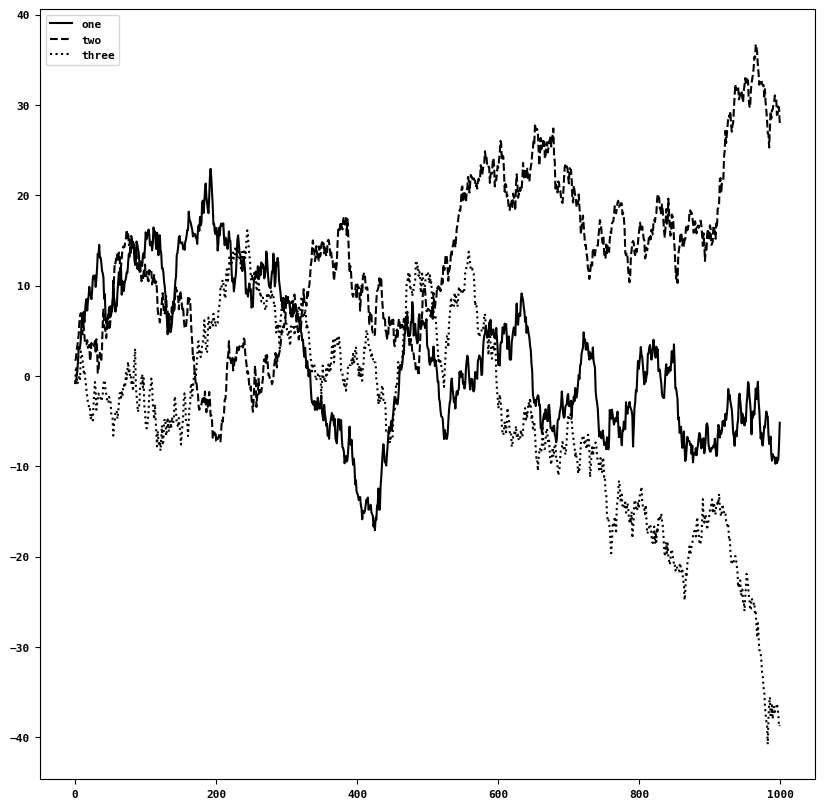

In [32]:
plt.rc("font", family = "monospace", weight = "bold", size = 8)
plt.rc("figure", figsize = (10,10))
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color="black", label="one")
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dashed",
        label="two")
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dotted",
        label="three")
       
ax.legend()

- 설정된 값을 원래대로 돌리고 싶다면

In [33]:
plt.rcdefaults()

# Pandas를 활용한 Plotting

- Matplotlib은 저수준의 library
- Pandas.DataFrame의 메서드를 활용하여 간단한 시각화가 가능

In [34]:
df = pd.DataFrame({'length': [1.5, 0.5, 1.2, 0.9, 3],
                    'width': [0.7, 0.2, 0.15, 0.2, 1.1]},
                    index = ['pig', 'rabbit', 'duck', 'chicken', 'horse'])
df

,length,width
pig,1.5,0.70
rabbit,0.5,0.20
duck,1.2,0.15
chicken,0.9,0.20
horse,3.0,1.10


- 기본그림 (line plot)

<Axes: title={'center': 'DataFrame Plot'}>

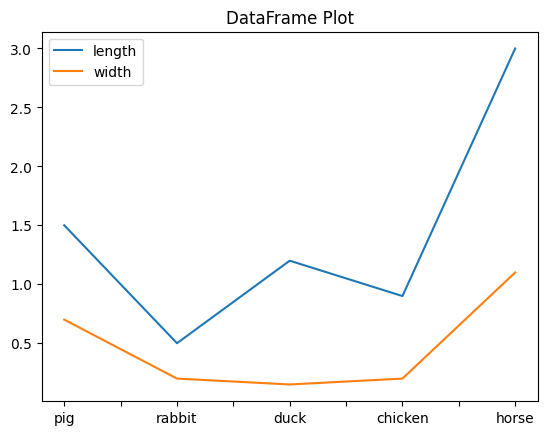

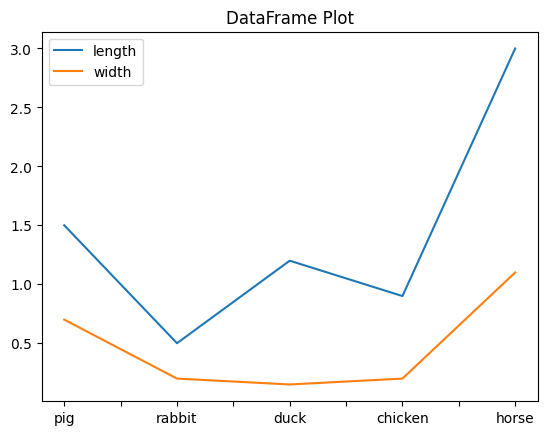

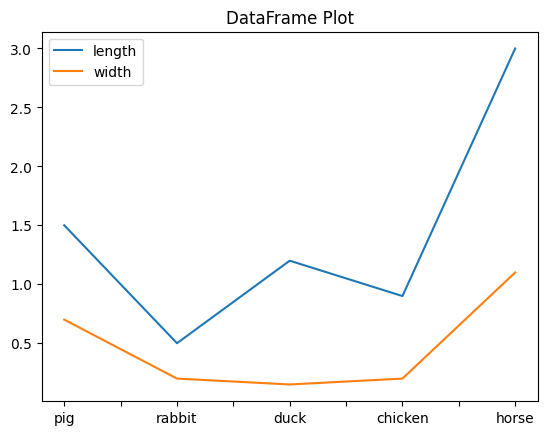

In [38]:
df.plot(title = "DataFrame Plot") # default
df.plot(title = "DataFrame Plot", kind = "line")
df.plot.line(title = "DataFrame Plot")

- 그림 종류

| 그림 | method | kind |
| --- | --- | --- |
| 선그림 | plot.line(x) | “line” |
| 면적그림 | plot.area(x) | “area” |
| 산점도 | plot.scatter(x, y) | “scatter” |
| 막대그림 | plot.bar() | “bar” |
| 수평막대그림 | plot.barh() | “barh” |
| 히스토그램 | plot.hist() | “hist” |
| 파이차트 | plot.pie() | “pie” |
| 상자그림 | plot.box() | “box” |
| 밀도함수그림 | plot.density() / plot.kde() | “density”, “kde” |
| 커널밀도함수 |  | “kde” |
| Hexbin | plot.hexbin() | “hexbin” |
- 면적그림 (area plot)

<Axes: >

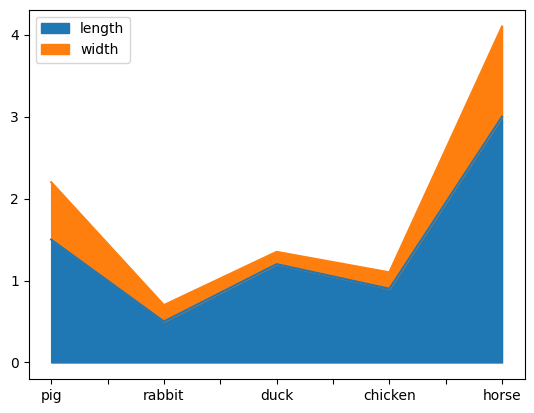

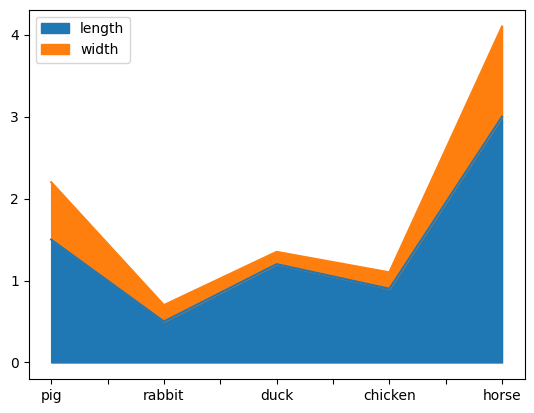

In [37]:
df.plot(kind = "area")
df.plot.area()

- 산점도 (연속 vs 연속)

<Axes: xlabel='length', ylabel='width'>

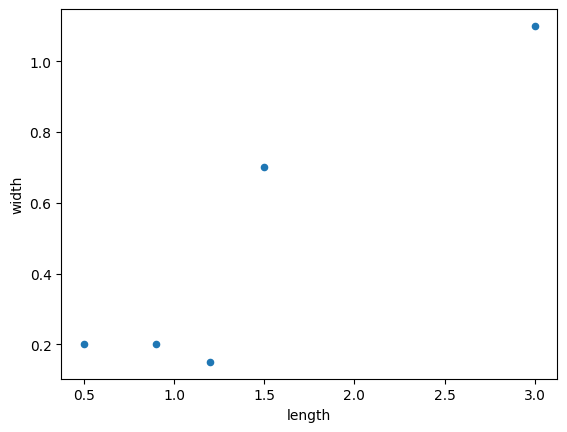

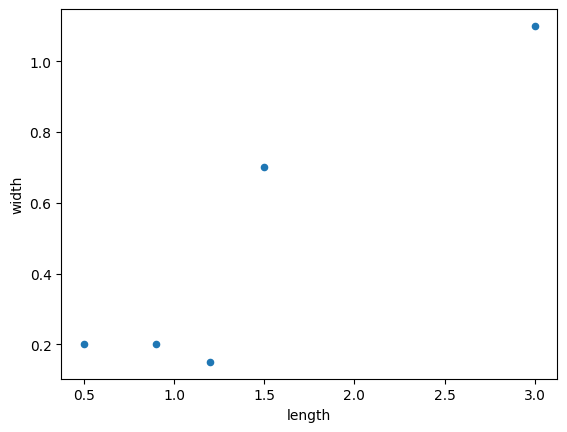

In [39]:
df.plot("length", "width", kind = "scatter") # or
df.plot.scatter("length", "width")

- 막대그림 / 수평막대그림 (범주 vs 연속)

<Axes: >

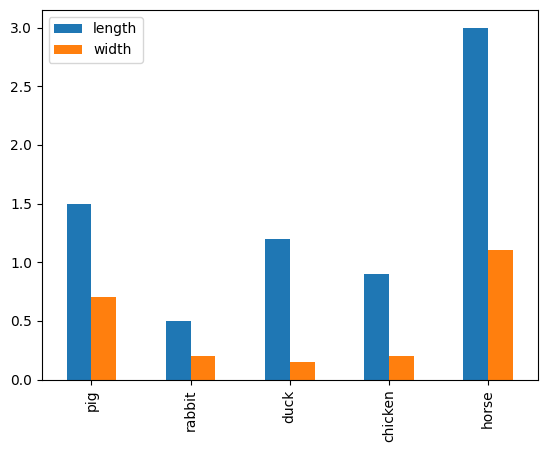

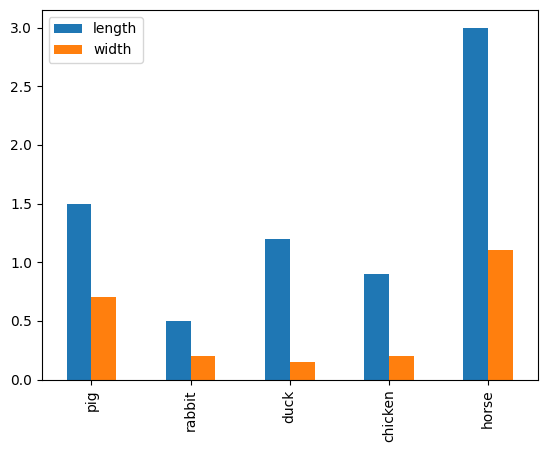

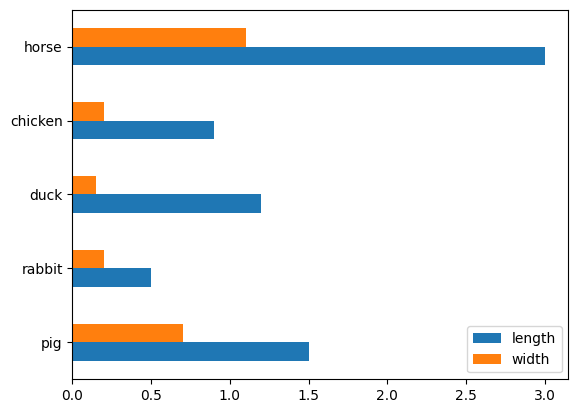

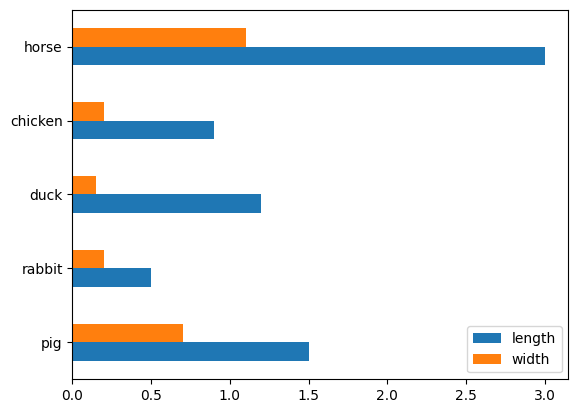

In [40]:
df.plot(kind = "bar") # or
df.plot.bar()

df.plot(kind = "barh") # or
df.plot.barh()

- 분포의 요약: 히스토그램 / 상자그림 / 밀도그림 / 커널밀도그림

In [41]:
df = pd.DataFrame(np.random.randint(1, 7, 1000), columns=['one'])
df['two'] = df['one'] + np.random.randint(1, 7, 1000)
df

,one,two
0,2,5
1,6,7
2,4,6
3,1,5
4,1,2
...,...,...
995,6,10
996,6,12
997,1,3
998,4,5


<Axes: ylabel='Density'>

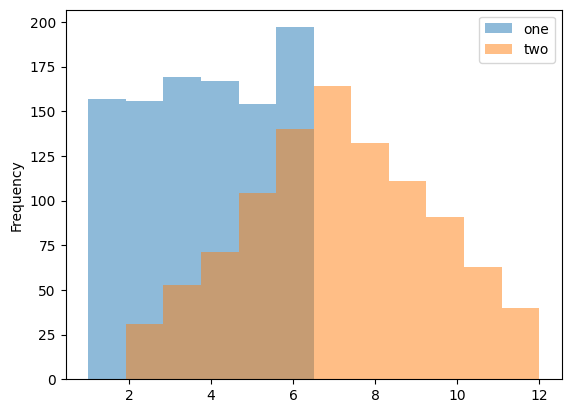

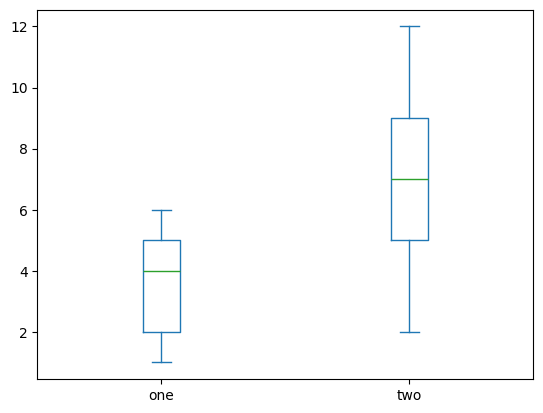

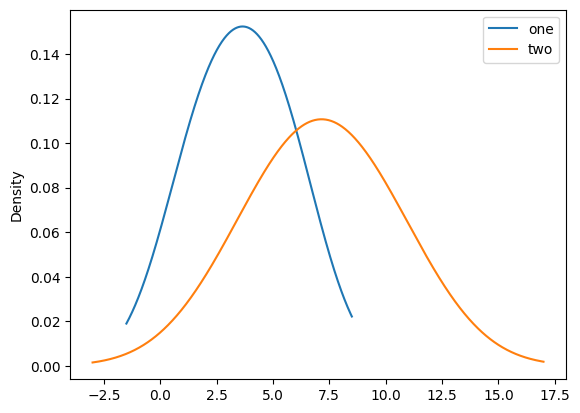

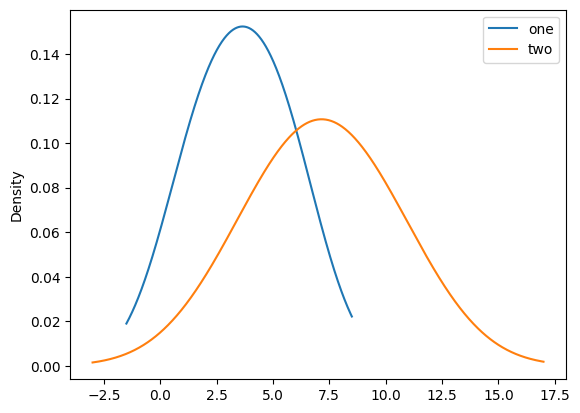

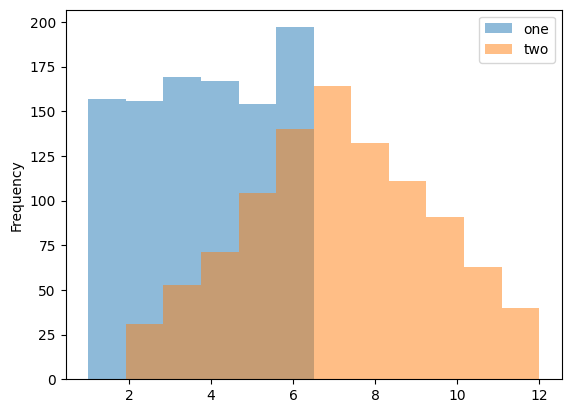

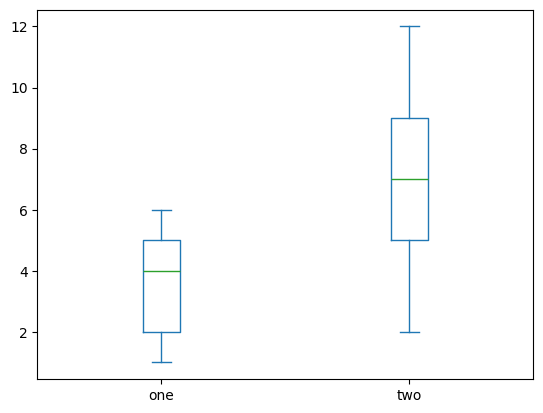

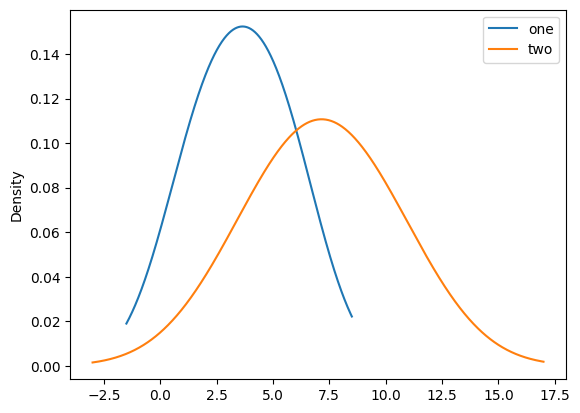

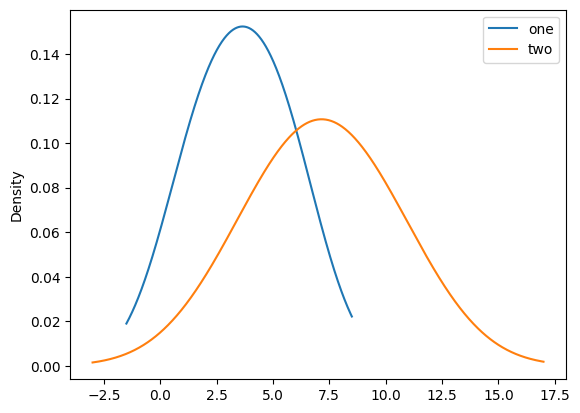

In [42]:
df.plot(kind = "hist", bins=12, alpha=0.5)
df.plot(kind = "box")
df.plot(kind = "density", bw_method = 1)
df.plot(kind = "kde", bw_method = 1)

# or
df.plot.hist(bins = 12, alpha = 0.5)
df.plot.box()
df.plot.density(bw_method = 1)
df.plot.kde(bw_method = 1)

- Hexbin

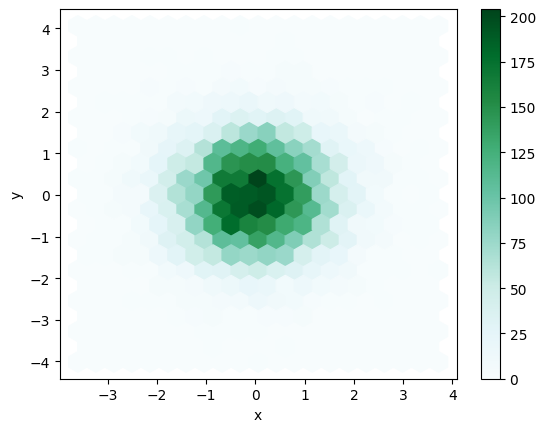

In [43]:
n = 10000
df = pd.DataFrame({'x': np.random.randn(n),
                   'y': np.random.randn(n)})
ax = df.plot.hexbin(x='x', y='y', gridsize=20)

# Seaborn

- Statistical Data Visualization Library based on Matplotlib.
- Integrates closely with Pandas data structure.
- It can handle both DataFrame and Array.
- Internally perform the mapping and statistical aggregation to produce informative plot.
- Online Manual: https://seaborn.pydata.org/

In [1]:
# !pip install seaborn
import seaborn as sns

In [21]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
# Load Example Data
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
# Load an example dataset
sns.set_theme() 

- seaborn.set_theme(style = … )
    - darkgrid
    - whitegrid
    - dark
    - white
    - ticks

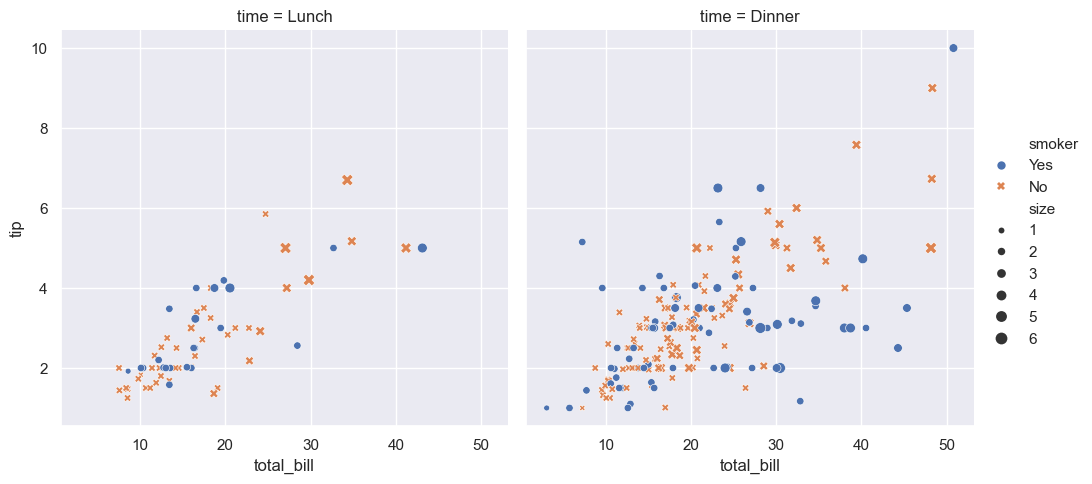

In [5]:
# Create a visualization
sns.relplot( # relational plot!
    data = tips,
    x = "total_bill", 
    y = "tip", 
    col = "time",     # facet
    hue = "smoker",   # color
    style = "smoker", # marker style
    size = "size"     # marker size
)

### S.1. Relationship - *replot()*

- https://seaborn.pydata.org/tutorial/relational.html
- Designed to visualize many different statistical *relationships*.

In [9]:
# load sample data
dots = sns.load_dataset("dots")
dots

,align,choice,time,coherence,firing_rate
0,dots,T1,-80,0.0,33.189967
1,dots,T1,-80,3.2,31.691726
2,dots,T1,-80,6.4,34.279840
3,dots,T1,-80,12.8,32.631874
4,dots,T1,-80,25.6,35.060487
...,...,...,...,...,...
843,sacc,T2,300,3.2,33.281734
844,sacc,T2,300,6.4,27.583979
845,sacc,T2,300,12.8,28.511530
846,sacc,T2,300,25.6,27.009804


- Line Plot

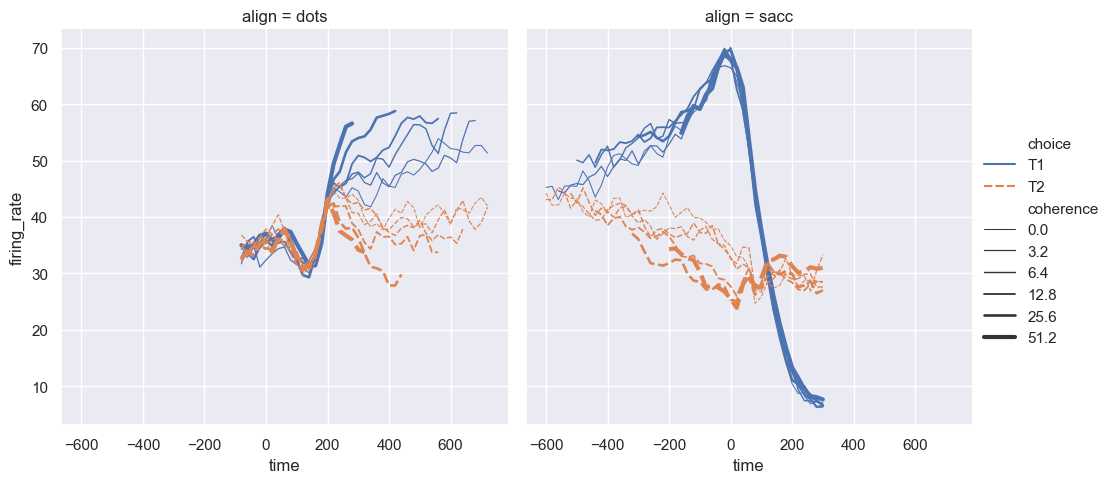

In [10]:
sns.relplot(
    data = dots, 
    kind = "line", # or 'scatter' -> default!
    x = "time", 
    y = "firing_rate", 
    col = "align",
    hue = "choice", 
    size = "coherence", 
    style = "choice"
    )

### S.2. Distribution - *displot()*

- https://seaborn.pydata.org/tutorial/distributions.html
- Visualizing distributions:
    - kind = “hist” - histgram (default)
    - kind = “kde” - Kernel Density Estimator
    - kind = “ecdf” - Empirical Cumulative Distribution Function

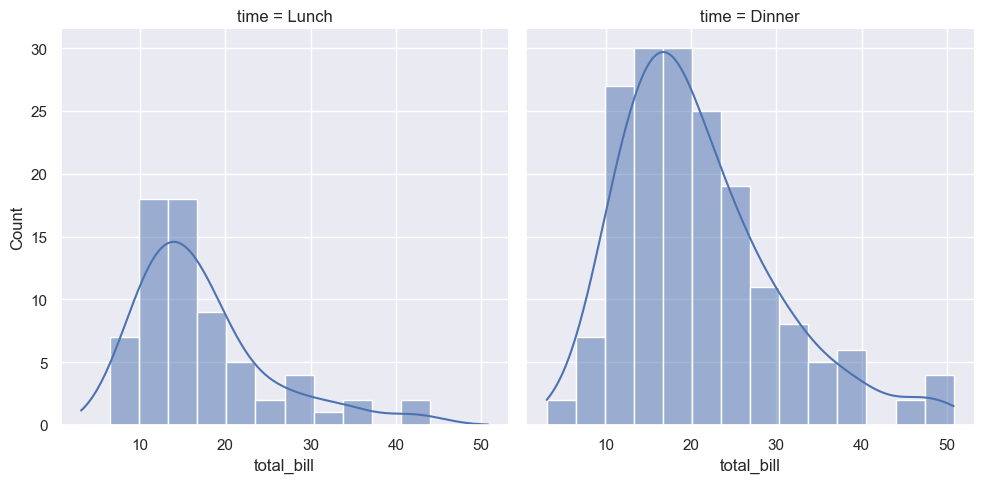

In [11]:
sns.displot(data = tips, 
            x = "total_bill", 
            col = "time", 
            kde = True)

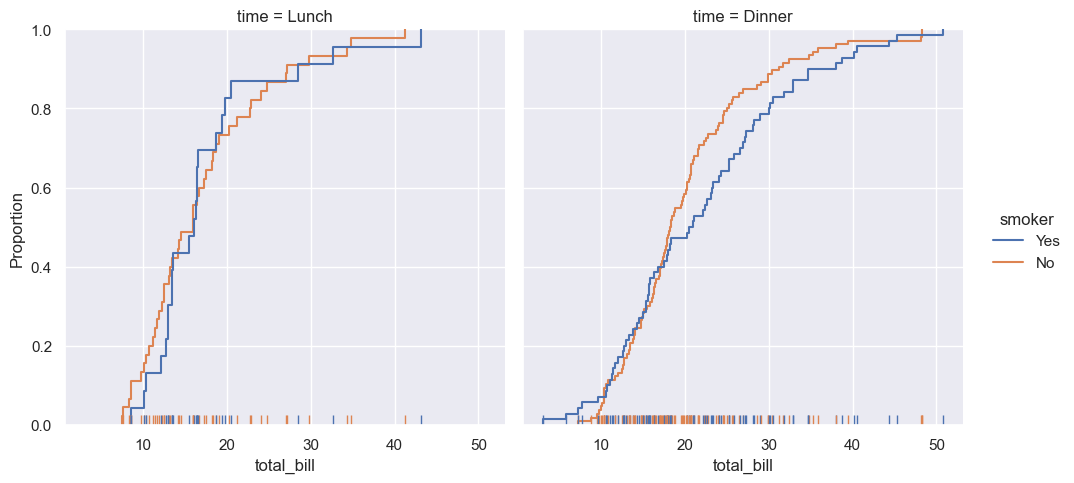

In [12]:
sns.displot(data = tips, 
            kind = "ecdf", 
            x = "total_bill", 
            col = "time", 
            hue = "smoker", 
            rug = True)

### S.3. Categorical Data - *catplot()*

- https://seaborn.pydata.org/tutorial/categorical.html
- visualizing categorical data
- 종류 (kind = … )
    - Scatter Plots
        - “strip”
        - “swarm”
    - Distribution Plots
        - “box”
        - “violin”
        - “boxen”
    - Estimate Plot
        - “point”
        - “bar”
        - “count”
- Scatter Plots

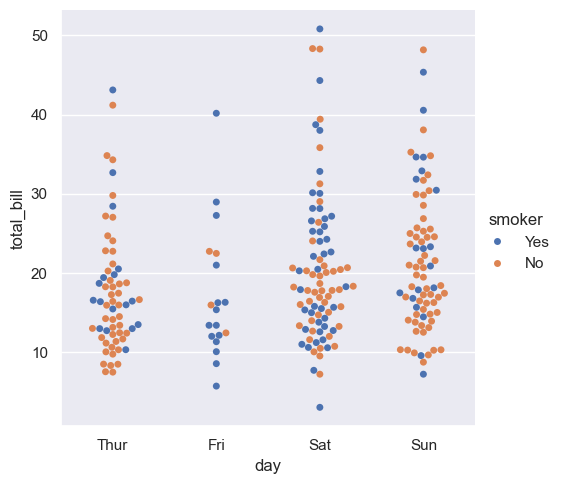

In [13]:
sns.catplot(data = tips, 
            kind = "swarm", # or" strip"
            x = "day", 
            y = "total_bill", 
            hue = "smoker")

- Distribution Plot

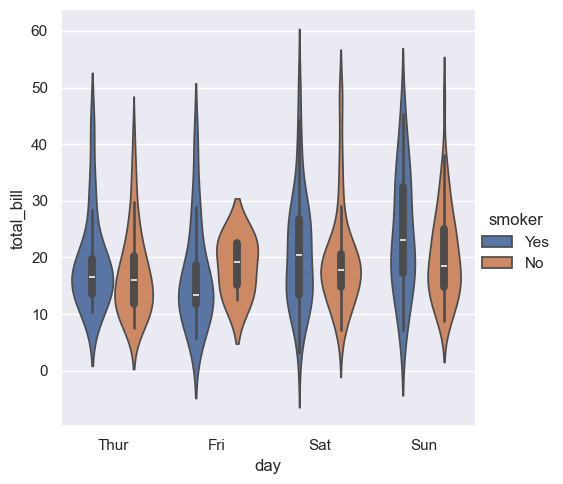

In [14]:
# Violin 
sns.catplot(data = tips, 
            kind = "violin", # "box" or "boxen"
            x = "day", 
            y = "total_bill", 
            hue = "smoker")

- Estimate Plots
    - https://seaborn.pydata.org/tutorial/error_bars.html
    - 통계량 (평균 or 도수) 과 신뢰구간을 제공

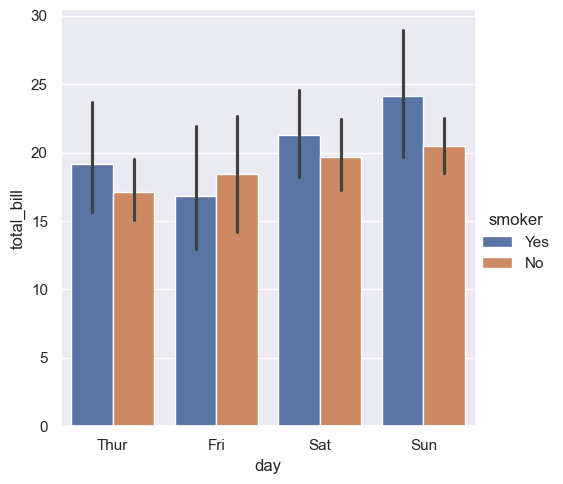

In [15]:
sns.catplot(data = tips, 
            kind = "bar", 
            x = "day", 
            y = "total_bill", 
            hue = "smoker")

### S.4. Regression Plot

- https://seaborn.pydata.org/tutorial/regression.html#
- lmplot: Scatter plot + Fitted Regression Lines (linear / logistic / lowess)

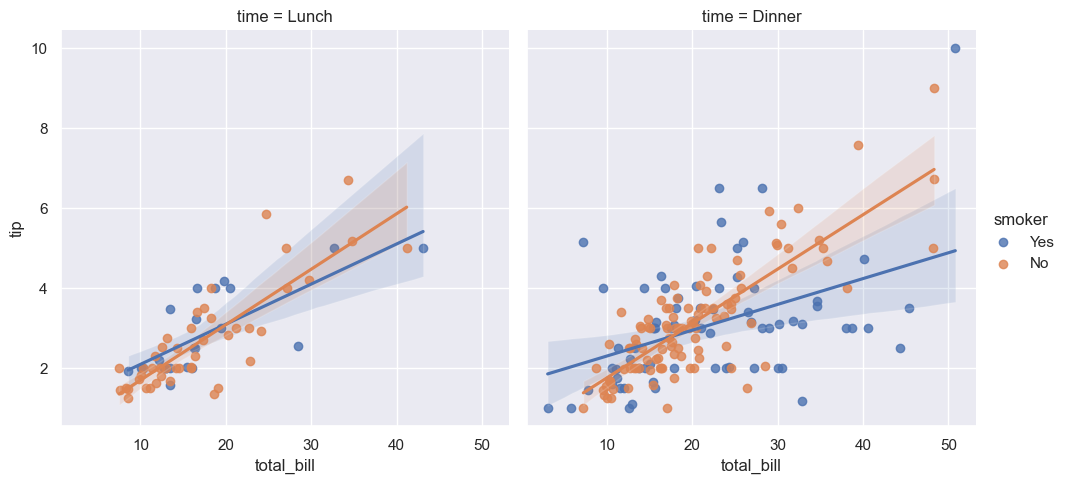

In [16]:
sns.lmplot(data = tips, 
           x = "total_bill", 
           y = "tip", 
           col = "time", 
           hue = "smoker")

### S.5. Plots for Complex Data

- Joint Plot - replot + displot

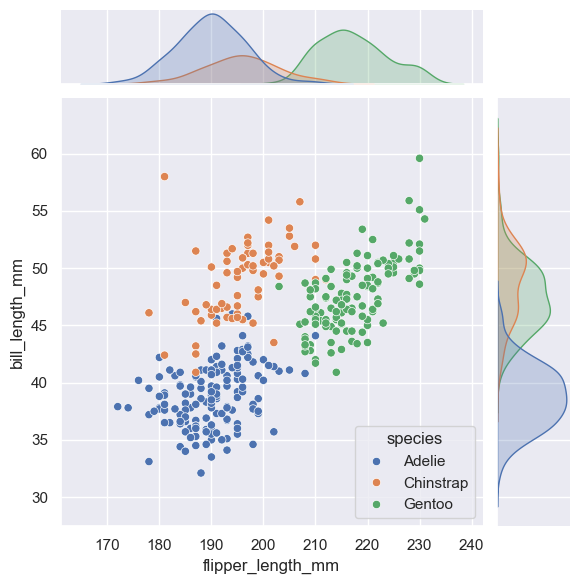

In [25]:
penguins = sns.load_dataset("penguins")
sns.jointplot(data=penguins, x = "flipper_length_mm", 
                             y = "bill_length_mm", 
                             hue = "species")

- Pairplot - Scatter Plot Matrix

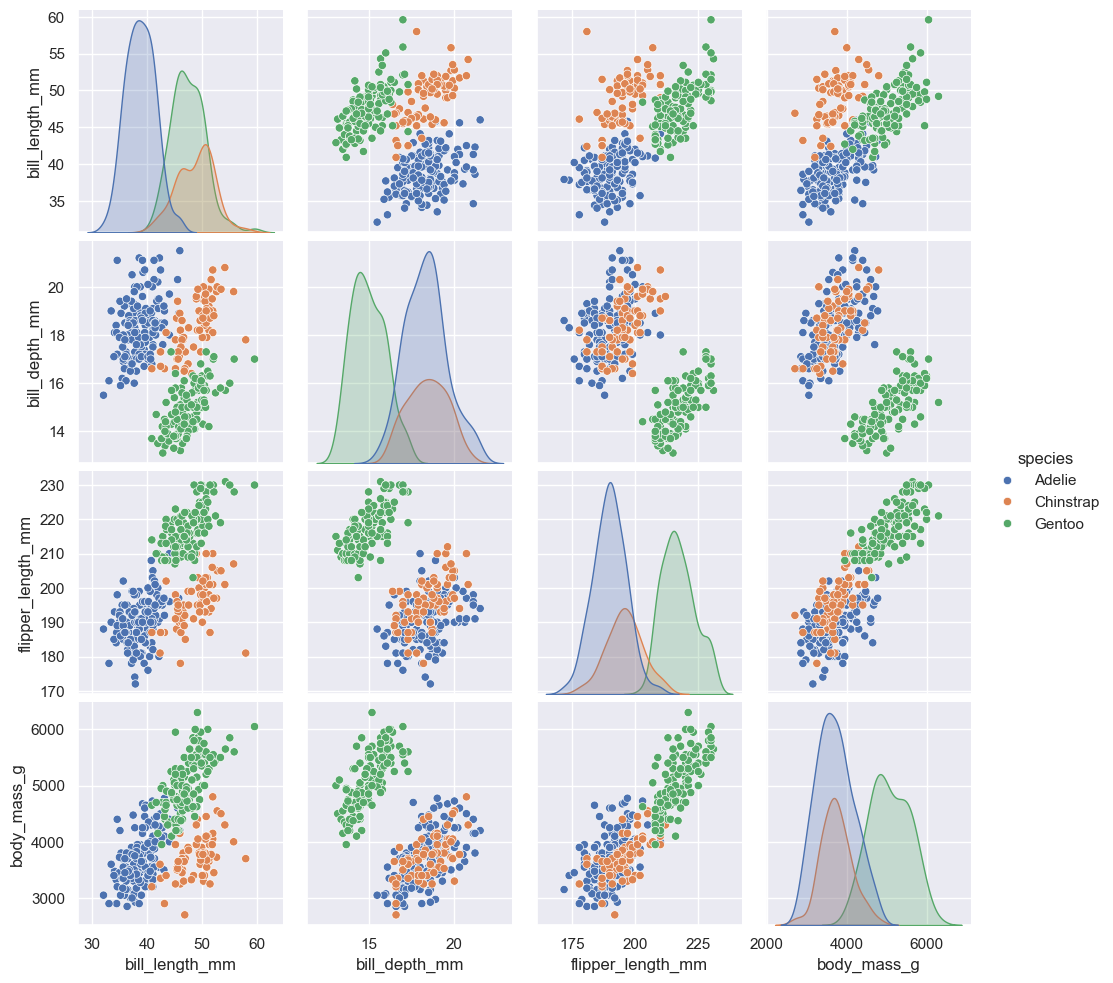

In [26]:
sns.pairplot(data = penguins, 
             hue = "species")

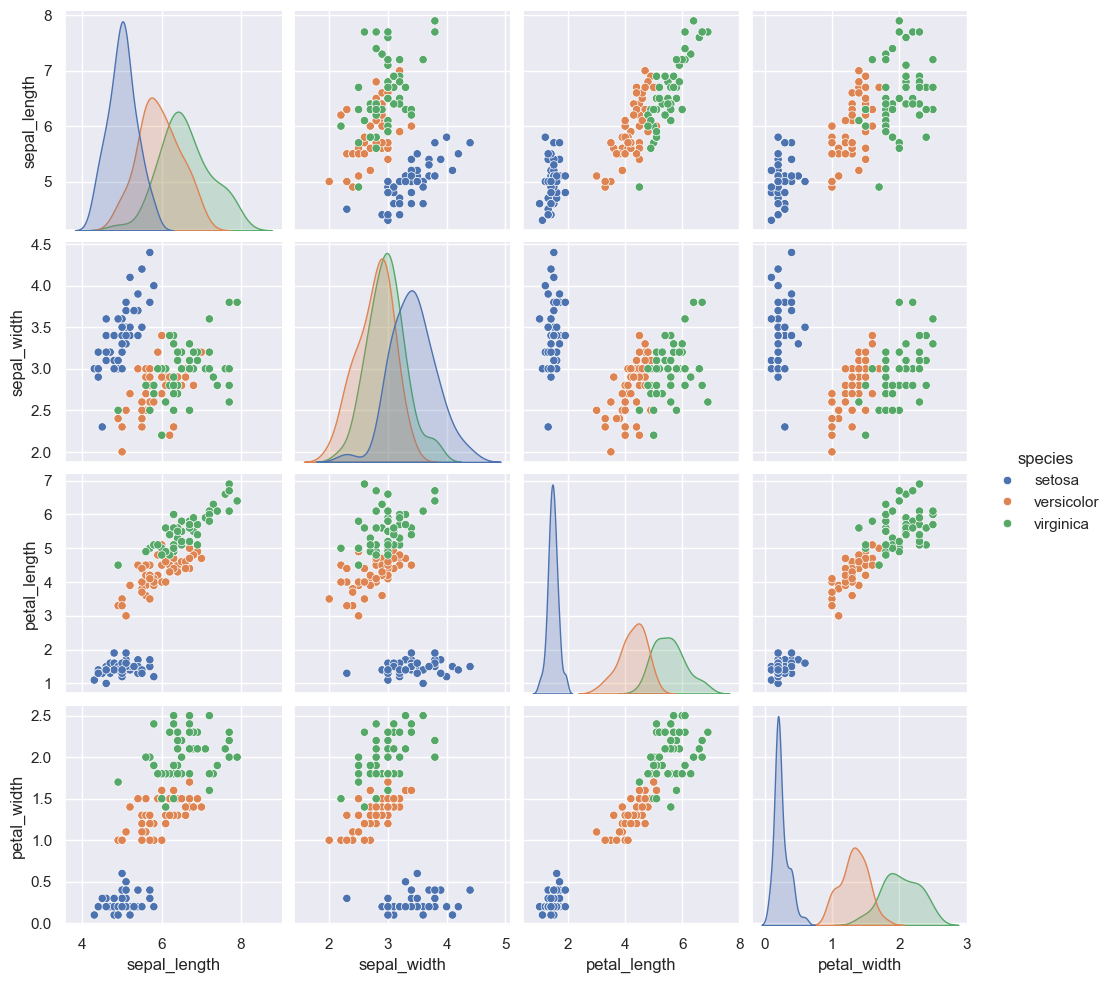

In [28]:
iris = sns.load_dataset("iris")
sns.pairplot(data = iris, hue = "species")

# Grammer of Graphics

- 그림 (plot) 이란 무엇인가?
- 그림을 보다 체계적으로 이해하고 표현할 수 없을까?
- 그림의 체계를 설명하기위한 문법 (grammar)를 만들면?
    - 다양한 종류의 그래프를 보다 체계적으로 이해할 수 있고,
    - 새로운 종류의 그래프를 만들고 프로그램화 하기 쉽다!
    
- 다음의 간단한 데이터를 예로 들어보자

| A | B | C | D |
| --- | --- | --- | --- |
| 2 | 3 | 4 | a |
| 1 | 2 | 1 | a |
| 4 | 5 | 15 | b |
| 9 | 10 | 80 | b |
- 위의 데이터로 산점도를 그리고자 한다. 산점도는 어떻게 정의되는가? 산점도를 컴퓨터에게 이해시키려면 어떻게 설명해야하는가?

- 그림은 다음과 같은 5개의 요소로 이루어짐
    - data
    - geometric object
    - mapping (variables to aesthetics)
    - scale & coordinate system
    - annotation

## GGplot2 in R

- A layered Grammar of Graphics (Hadley Wickham)

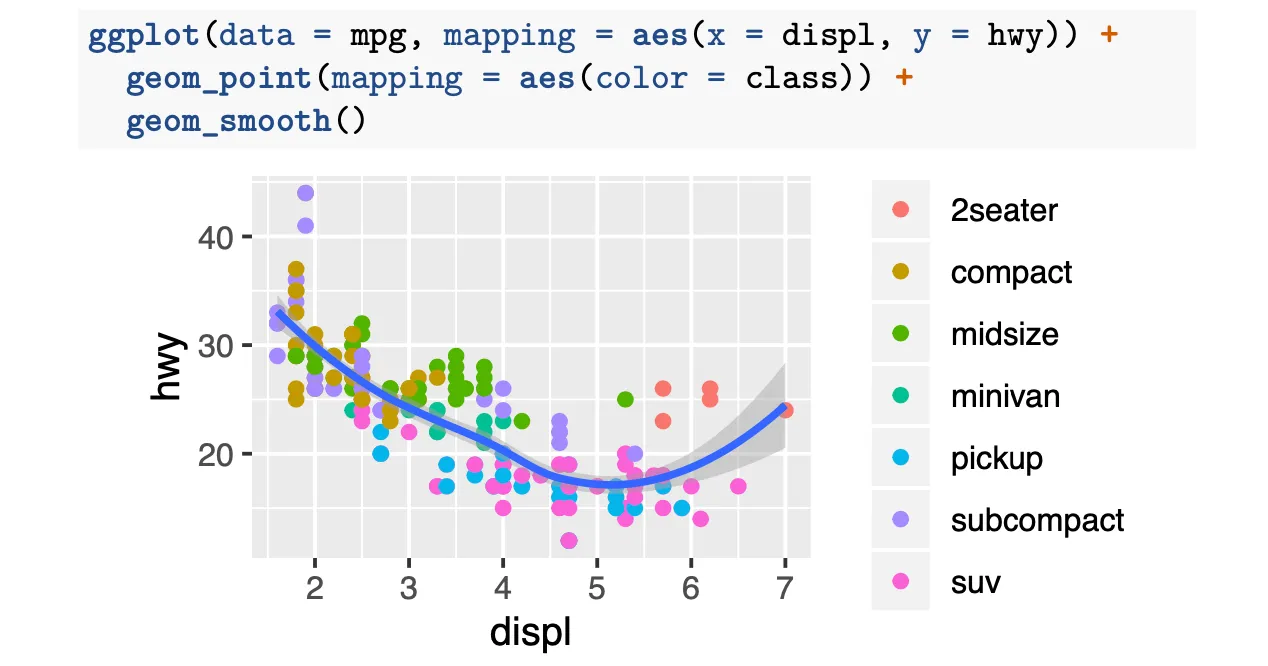

### Plotnine: GGplot2 in Python

- Python implementation of ggplot 2 in R
- https://plotnine.org/

In [29]:
# Install Library
!pip install plotnine

  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 7.1 MB/s eta 0:00:00a 0:00:01
Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)


- Example

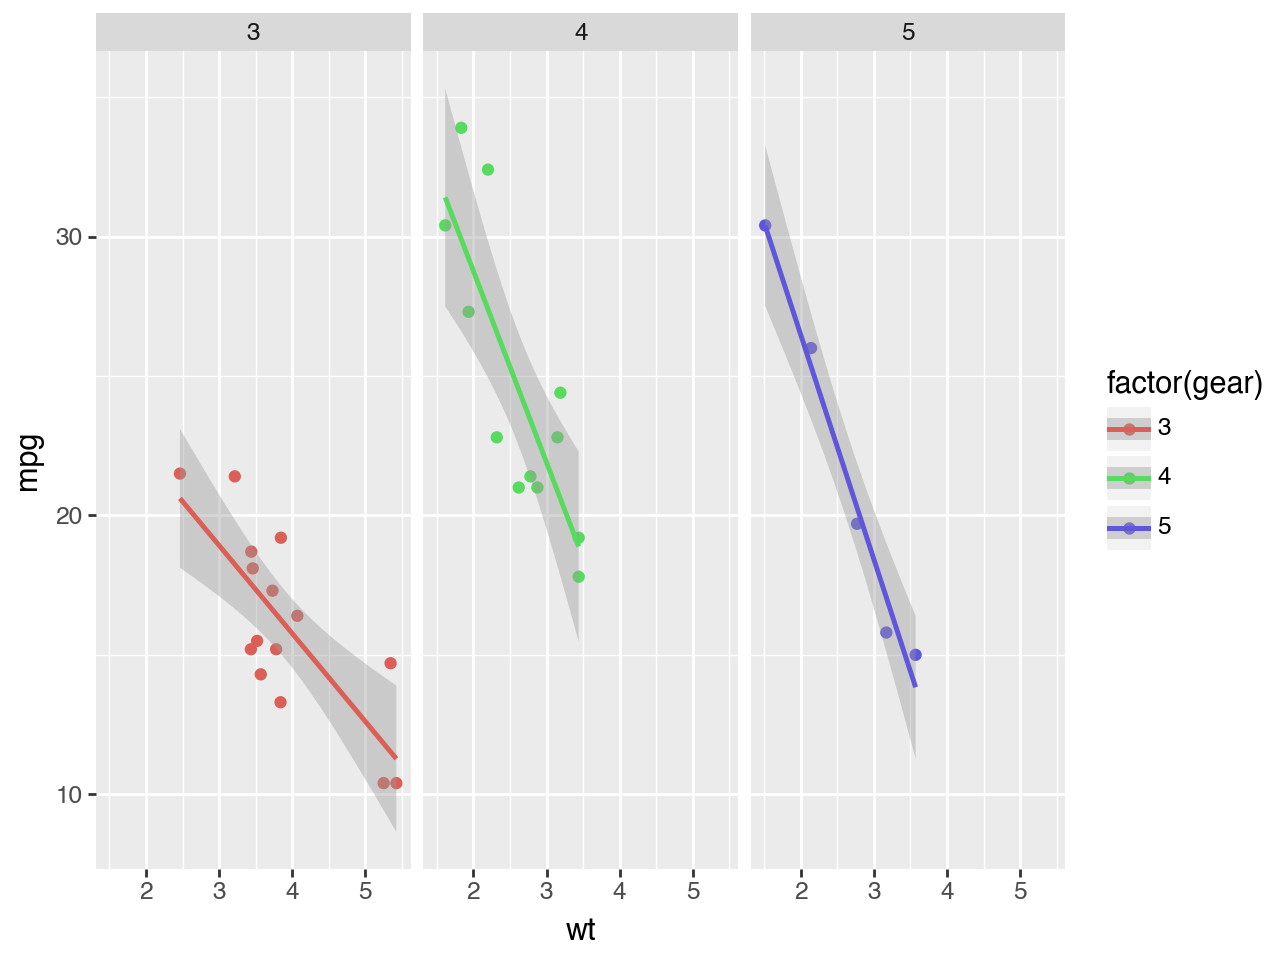

In [30]:
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap
from plotnine.data import mtcars

(
    ggplot(mtcars, aes("wt", "mpg", color="factor(gear)"))
    + geom_point()
    + stat_smooth(method="lm")
    + facet_wrap("gear")
)